# **Deep Learning Lab: Transfer Learning**

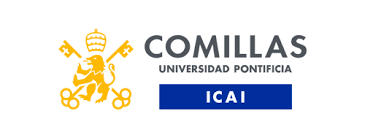

***

## Import packages

In [1]:
from cnn import CNN
import torchvision
from cnn import load_data
from cnn import load_model_weights
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import wandb

In [2]:
# Optional: install W&B once in this environment
# %pip install wandb
wandb.login(relogin=False)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/javi/.netrc.
wandb: Currently logged in as: javiag_ (javi_paula_julia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Model and data loading

In [3]:
# Pytorch has many pre-trained models that can be used for transfer learning
classification_models = torchvision.models.list_models(module=torchvision.models)
print(classification_models)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

In [4]:
# Load data and model 
train_dir = './dataset/training'
valid_dir = './dataset/validation'

train_loader, valid_loader, num_classes = load_data(train_dir, 
                                                    valid_dir, 
                                                    batch_size=32, 
                                                    img_size=224) # ConvNeXt-Base requires 224x224 images
model1 = CNN(torchvision.models.convnext_base(weights='DEFAULT'), num_classes, unfreezed_layers=0)
model2 = CNN(torchvision.models.efficientnet_b0(weights='DEFAULT'), num_classes, unfreezed_layers=0)
model3 = CNN(torchvision.models.resnet50(weights='DEFAULT'), num_classes, unfreezed_layers=0)

/opt/anaconda3/envs/dl_lab/lib/python3.12/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


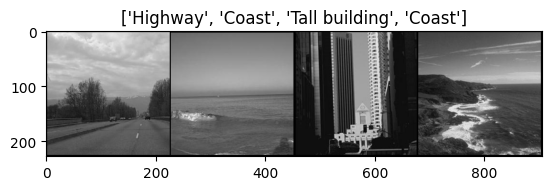

In [5]:
# Visualize a few images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a few random images
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = []
classes = []
for i in random_indices:
    inputs.append(valid_loader.dataset[i][0])
    classes.append(valid_loader.dataset[i][1])
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[classnames[x] for x in classes])

## Train

In [6]:
optimizer = torch.optim.AdamW(model1.parameters(), lr=3e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
history = model1.train_model(train_loader, valid_loader, optimizer, criterion, epochs=8, use_wandb=True, wandb_config={"dataset": "Scene Classification", "model": "ConvNeXt-Base", "epochs": 8, "unfrozen_layers": 0, "lr": "3e-5", "optimizer": "AdamW", "weight_decay": 0.01}, architecture="ConvNeXt-Base")

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12a190b90>> (for post_run_cell), with arguments args (<ExecutionResult object at 12a564230, execution_count=6 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 12a593200, raw_cell="optimizer = torch.optim.AdamW(model1.parameters(),.." transformed_cell="optimizer = torch.optim.AdamW(model1.parameters(),.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/javi/Desktop/ICAI/2Cuatri/MLII/DeepLearning/praticas/ImageClassification/03TransferLearning.ipynb#X26sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [ ]:
optimizer = torch.optim.AdamW(model2.parameters(), lr=3e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
history = model2.train_model(train_loader, valid_loader, optimizer, criterion, epochs=8, use_wandb=True, wandb_config={"dataset": "Scene Classification", "model": "EfficientNet-B0", "epochs": 8, "unfrozen_layers": 0, "lr": "3e-5", "optimizer": "AdamW", "weight_decay": 0.01}, architecture="EfficientNet-B0")

In [ ]:
optimizer = torch.optim.AdamW(model3.parameters(), lr=3e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
history = model3.train_model(train_loader, valid_loader, optimizer, criterion, epochs=8, use_wandb=True, wandb_config={"dataset": "Scene Classification", "model": "ResNet-50", "epochs": 8, "unfrozen_layers": 0, "lr": "3e-5", "optimizer": "AdamW", "weight_decay": 0.01}, architecture="ResNet-50")

In [ ]:
model1.save('convnext_base-8epoch')

In [ ]:
model2.save('efficientnet_b0-8epoch')

In [ ]:
model3.save('resnet50-8epoch')

## Predict

#### Load model

In [ ]:
# Load ConvNeXt-Base model for prediction
w1 = load_model_weights('convnext_base-8epoch')
m1 = CNN(torchvision.models.convnext_base(weights='DEFAULT'), num_classes, unfreezed_layers=0)
m1.load_state_dict(w1)
print('ConvNeXt-Base loaded')

In [ ]:
# Load EfficientNet-B0 model for prediction
w2 = load_model_weights('efficientnet_b0-8epoch')
m2 = CNN(torchvision.models.efficientnet_b0(weights='DEFAULT'), num_classes, unfreezed_layers=0)
m2.load_state_dict(w2)
print('EfficientNet-B0 loaded')

In [ ]:
# Load ResNet50 model for prediction
w3 = load_model_weights('resnet50-8epoch')
m3 = CNN(torchvision.models.resnet50(weights='DEFAULT'), num_classes, unfreezed_layers=0)
m3.load_state_dict(w3)
print('ResNet50 loaded')

## Results

In [ ]:
# Predict with ConvNeXt-Base
predicted_labels_m1 = m1.predict(valid_loader)
print('ConvNeXt-Base predictions:', len(predicted_labels_m1))

In [ ]:
# Predict with EfficientNet-B0
predicted_labels_m2 = m2.predict(valid_loader)
print('EfficientNet-B0 predictions:', len(predicted_labels_m2))

In [ ]:
# Predict with ResNet50
predicted_labels_m3 = m3.predict(valid_loader)
print('ResNet50 predictions:', len(predicted_labels_m3))

In [ ]:
# Visualize ConvNeXt-Base predictions
if 'random_indices' not in globals():
    random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = [valid_loader.dataset[i][0] for i in random_indices]
pred_classes = [predicted_labels_m1[i] for i in random_indices]
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[f"ConvNeXt-Base: {classnames[x]}" for x in pred_classes])

In [ ]:
# Visualize EfficientNet-B0 predictions (same images)
inputs = [valid_loader.dataset[i][0] for i in random_indices]
pred_classes = [predicted_labels_m2[i] for i in random_indices]
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[f"EfficientNet-B0: {classnames[x]}" for x in pred_classes])

In [ ]:
# Visualize ResNet50 predictions (same images)
inputs = [valid_loader.dataset[i][0] for i in random_indices]
pred_classes = [predicted_labels_m3[i] for i in random_indices]
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[f"ResNet50: {classnames[x]}" for x in pred_classes])